In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
%matplotlib inline

In [4]:
df1 = pd.read_csv("Dataset .csv")

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

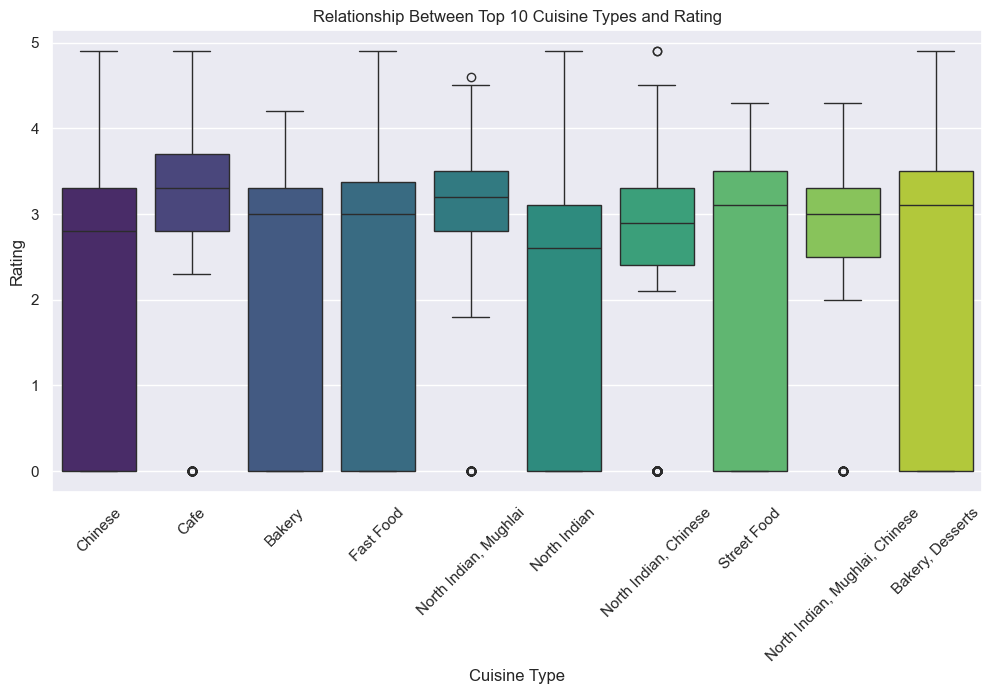

In [6]:
cuisines = df1["Cuisines"]

cuisines.value_counts().head(10)

top_10_cuisines = cuisines.value_counts().head(10).index

cuisine_ratings = pd.DataFrame({
    "Cuisine": cuisines,
    "Rating": df1["Aggregate rating"]
})

cuisine_ratings_top_10 = cuisine_ratings[
    cuisine_ratings["Cuisine"].isin(top_10_cuisines)
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Cuisine",
    y="Rating",
    data=cuisine_ratings_top_10,
    palette="viridis"
)

plt.title("Relationship Between Top 10 Cuisine Types and Rating")
plt.xlabel("Cuisine Type")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()

In [7]:
cuisine_votes = pd.DataFrame({
    "Cuisine": cuisines,
    "Votes": df1["Votes"]
})

cuisine_votes_sum = cuisine_votes.groupby("Cuisine")["Votes"].sum()

popular_cuisines = cuisine_votes_sum.sort_values(ascending=False)

print("Top 10 Most Popular Cuisines Based on Number of Votes:")
print(popular_cuisines.head(10))

Top 10 Most Popular Cuisines Based on Number of Votes:
Cuisine
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64


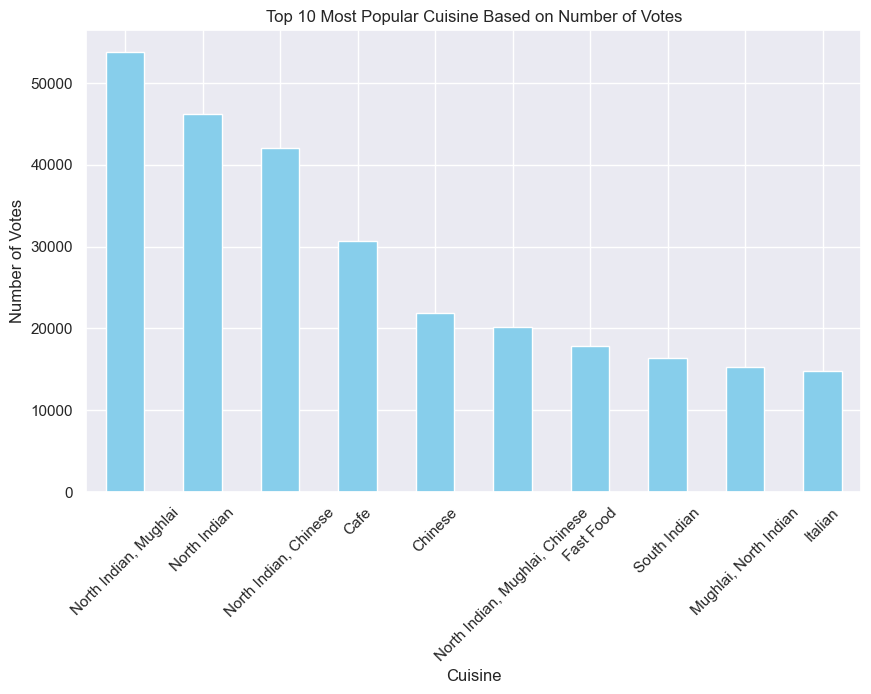

In [8]:
plt.figure(figsize=(10, 6))

popular_cuisines.head(10).plot(
    kind="bar",
    color="skyblue"
)

plt.title("Top 10 Most Popular Cuisine Based on Number of Votes")
plt.xlabel("Cuisine")
plt.ylabel("Number of Votes")
plt.xticks(rotation=45)

plt.show()

In [9]:
cuisine_ratings = pd.DataFrame({
    "Cuisine": cuisines,
    "Rating": df1["Aggregate rating"]
})

average_rating_by_cuisine = (
    cuisine_ratings.groupby("Cuisine")["Rating"].mean()
)

sorted_cuisines_by_rating = (
    average_rating_by_cuisine.sort_values(ascending=False)
)

print("Top 10 Cuisines with the Highest Average Ratings:")
print(sorted_cuisines_by_rating.head(10))

Top 10 Cuisines with the Highest Average Ratings:
Cuisine
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Rating, dtype: float64


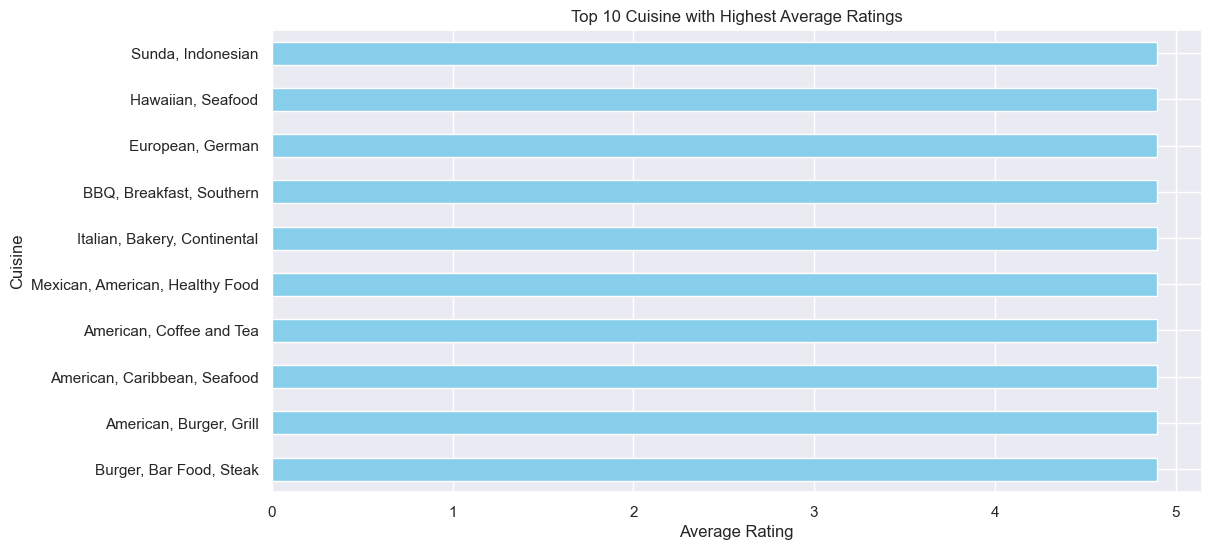

In [10]:
plt.figure(figsize=(12, 6))

sorted_cuisines_by_rating.head(10).plot(
    kind="barh",
    color="skyblue"
)

plt.title("Top 10 Cuisine with Highest Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()